# Polar plot
Based on https://github.com/climberlenny/test_openberg/blob/main/toolbox/postprocessing.py

In [1]:
cd ~/work/tutorials/sources/OpenDrift/openberg_custom_juliette 

/home/jovyan/work/tutorials/sources/OpenDrift/openberg_custom_juliette


In [2]:
from src.utils import *
from src.utils2 import *

In [3]:
# Read and subset tracker data
obs = read_tracker('./input/Osker-X2.csv')['full']
# Read simulation data
sim = xr.open_dataset('./results/juliette_topaz4_windglophynrt.nc')
note = 'topaz4_windglophynrt'

/home/jovyan/work/tutorials/sources/OpenDrift/openberg_custom_juliette/src/utils2.py:108: UserWarning: Parsing dates in %d/%m/%Y %H:%M:%S format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df['time'] = pd.to_datetime(df['Date'] + ' ' + df['Time'])


In [4]:
# --- Processing before plotting ---
# Create obs-sim pairs by a) looking for the cloosest observation time for every simulation time,
# b) subset (both datasets) to 6hourly or daily frequnecy, then as a),
# or c) looking for closest sim in obs.time.

# a)Selects the nearest times in obs for every sim.time whihc is hourly
obs_simfreq = obs.sel(time=sim.time, method="nearest") 
# b)
sim_daily = sim.resample(time="1D").first() #.mean() 
sim_6h = sim.sel(time=sim.time.dt.hour.isin([0, 6, 12, 18]))
sim_6h.time
obs_dailysimfreq = obs.sel(time=sim_daily.time, method="nearest") 
# c)
sim_obstime = sim.sel(time=obs.time, method="nearest") 
sim_obstime.time

#or daily averages?
#Cut off from 5 Dec on as no sim results!

<xarray.DataArray 'time' (time: 250)> Size: 2kB
array(['2025-09-24T00:00:31.000000000', '2025-09-24T06:00:31.000000000',
       '2025-09-24T12:00:31.000000000', ..., '2025-12-05T00:00:31.000000000',
       '2025-12-05T00:00:31.000000000', '2025-12-05T00:00:31.000000000'],
      shape=(250,), dtype='datetime64[ns]')
Coordinates:
  * time     (time) datetime64[ns] 2kB 2025-09-24T00:00:31 ... 2025-12-05T00:...
Attributes:
    standard_name:  time
    long_name:      time

In [5]:
from scipy.spatial.distance import pdist

def polar_to_cartesian(theta, r):
    """Convert polar coordinates to Cartesian coordinates."""
    x = r * np.cos(theta)
    y = r * np.sin(theta)
    return x, y

def create_density_grid(points, grid_size=100, c=0.5):
    points = points[~np.isnan(points).any(axis=1)]
    # Calculer la distance moyenne entre les points
    d_avg = calculate_average_distance(points) + 1
    # Déterminer sigma en fonction de d_avg et du paramètre c
    sigma = c * d_avg

    # Déterminer les limites de la grille
    x_min, x_max = min(points[:, 0]) - 2 * sigma, max(points[:, 0]) + 2 * sigma
    y_min, y_max = min(points[:, 1]) - 2 * sigma, max(points[:, 1]) + 2 * sigma

    # Créer une grille de coordonnées
    x = np.linspace(x_min, x_max, grid_size)
    y = np.linspace(y_min, y_max, grid_size)
    X, Y = np.meshgrid(x, y)

    # Initialiser la grille de densité
    density_grid = np.zeros((grid_size, grid_size))

    # Nombre de points
    N = len(points)

    # Appliquer la distribution gaussienne à chaque point
    for point in points:
        dx = X - point[0]
        dy = Y - point[1]
        r = np.sqrt(dx**2 + dy**2)
        density_grid += gaussian_kernel(r, sigma) / N

    return X, Y, density_grid

def calculate_average_distance(points):
    if len(points) > 1000:
        distances = pdist(points[::50])
    else:
        distances = pdist(points)
    d_avg = np.mean(distances)
    return d_avg
    
def gaussian_kernel(r, sigma):
    return np.exp(-(r**2) / (2 * sigma**2)) / (2 * np.pi * sigma**2)

def find_contour_levels(density_grid, percentages):
    sorted_density = np.sort(density_grid.ravel())[::-1]
    cumsum_density = np.cumsum(sorted_density)
    total_density = cumsum_density[-1]
    levels = [
        sorted_density[np.searchsorted(cumsum_density, p * total_density)]
        for p in percentages
    ]
    levels.sort()  # S'assurer que les niveaux sont dans l'ordre croissant
    return levels



/tmp/ipykernel_12786/2998221075.py:15: RuntimeWarning: invalid value encountered in divide
  vel1 = distance1 / dt #distance/seconds
/tmp/ipykernel_12786/2998221075.py:19: RuntimeWarning: divide by zero encountered in divide
  R = np.where(vel0>0,vel1 / vel0,np.nan) # if vel0 > 0 else 0
/tmp/ipykernel_12786/2998221075.py:19: RuntimeWarning: invalid value encountered in divide
  R = np.where(vel0>0,vel1 / vel0,np.nan) # if vel0 > 0 else 0


3.069238778023053 2.264732001160406 1012.4048823230352


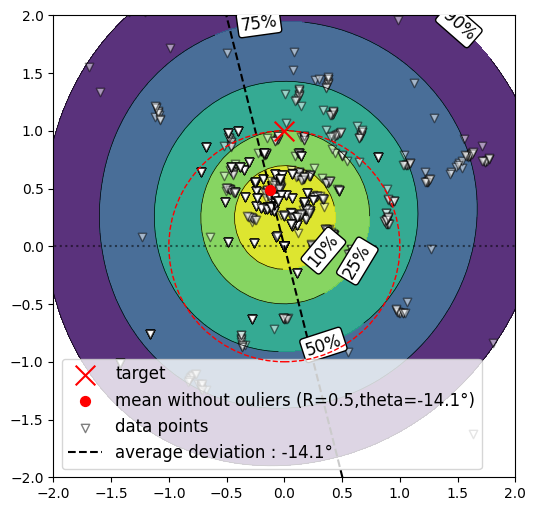

In [6]:
import pyproj
from scipy.stats import circmean
geod = pyproj.Geod(ellps="WGS84")

# observation = ref
azimuth_alpha, a2, distance0 = geod.inv(
    obs.lon[:-1],obs.lat[:-1],obs.lon[1:],obs.lat[1:])
dt = np.diff(obs.time) / np.timedelta64(1, "s")  #individual timesteps between the points
vel0 = distance0 / dt #distance/seconds
vel0
# simulation
azimuth_betha, a2, distance1 = geod.inv(
    sim_obstime.lon[:,:-1],sim_obstime.lat[:,:-1],sim_obstime.lon[:,1:],sim_obstime.lat[:,1:])
dt = np.diff(sim_obstime.time) / np.timedelta64(1, "s") #individual timesteps between the points
vel1 = distance1 / dt #distance/seconds

# calculate the coordinates in the polar plot
THETA = np.array((azimuth_betha - azimuth_alpha + 360) % 360)
R = np.where(vel0>0,vel1 / vel0,np.nan) # if vel0 > 0 else 0

#average meassures:
r_avg_with_outsiders = np.nanmean(R)
theta_avg_with_outsiders = circmean(THETA[~np.isnan(THETA)])
print(theta_avg_with_outsiders, r_avg_with_outsiders, np.nanmax(R))

#calc insiders and gridded densities:
outsiders = (R > 3).sum() / len(R) * 100
# Convert polar coordinates to Cartesian coordinates
x, y = polar_to_cartesian(np.pi / 2 - np.radians(THETA[R <= 3]), R[R <= 3])
x_outsiders, y_outsiders = polar_to_cartesian(
    np.pi / 2 - np.radians(theta_avg_with_outsiders), r_avg_with_outsiders)
r_avg_insiders = np.mean(R[R <= 3])
theta_avg_insiders = circmean(THETA[R <= 3], high=360, low=0)
x_insiders, y_insiders = polar_to_cartesian(
    np.pi / 2 - np.radians(theta_avg_insiders), r_avg_insiders)

grid_size = 100
percentages = [0.9, 0.75, 0.5, 0.25, 0.1, 0]
points_insiders = np.vstack((x, y)).T
X, Y, density_grid = create_density_grid(points_insiders, grid_size, c=0.5)
levels = find_contour_levels(density_grid, percentages)

fig, ax = plt.subplots(figsize=(6, 6))
contourf = ax.contourf(
    X,
    Y,
    density_grid,
    levels=levels,
    cmap="viridis",
    alpha=0.9,
)
contour = ax.contour(
    X,
    Y,
    density_grid,
    levels=levels,
    colors="k",
    linewidths=(0.5,),
)
clabels = ax.clabel(
    contour,
    inline=True,
    fontsize=12,
    fmt={level: f"{int(p*100)}%" for level, p in zip(levels, percentages)},
)
## Customize clabels
for txt in clabels:
    txt.set_bbox(
        dict(facecolor="white", edgecolor=txt.get_color(), boxstyle="round,pad=0.2")
    )
    txt.set_color("black")

ax.scatter(0, 1, marker="x", s=200, c="r", label="target", zorder=20)
ax.scatter(
    x_insiders,
    y_insiders,
    marker="o",
    s=50,
    c="r",
    label=f"mean without ouliers (R={np.round(r_avg_insiders,1)},theta={np.round(theta_avg_insiders,1) if theta_avg_insiders<180 else np.round(theta_avg_insiders-360,1)}°)",
    zorder=30,
)
ax.scatter(
    x, y, alpha=0.5, marker="v", color="white", edgecolor="k", label="data points"
)
ax.plot(
    np.linspace(-3, 3, 100),
    np.tan(np.pi / 2 - np.deg2rad(theta_avg_insiders)) * np.linspace(-3, 3, 100),
    color="k",
    linestyle="--",
    label=f"average deviation : {np.round(theta_avg_insiders,1) if theta_avg_insiders<180 else np.round(theta_avg_insiders-360,1)}°",
)
ax.hlines(0, xmin=-5, xmax=5, linestyle=":", color="k", alpha=0.5)
ax.set_xlim([-2, 2])
ax.set_ylim([-2, 2])
circle1 = plt.Circle(
    (0, 0), 1, edgecolor="r", linestyle="--", fc=None, fill=False, zorder=30
)
ax.add_patch(circle1)
plt.legend(loc="lower left", fontsize=12)
plt.gca().set_aspect(
    "equal", adjustable="box"
)  # Set aspect ratio to make it look polar
plt.savefig('./results/polarplot_%s.png'%(note), bbox_inches="tight", dpi=400)
plt.show()

In [7]:
# plt.plot(range(obs.time.size), obs.time)
# plt.plot(range(sim_obstime.time.size),sim_obstime.time)